In [1]:
!pip install ucimlrepo -q
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os
from ucimlrepo import fetch_ucirepo

steel = fetch_ucirepo(id=851)
df = steel.data.features.copy()

# Nowe kolumny
df['hour'] = (df['NSM'] // 3600).astype(int)
df['pora_dnia'] = pd.cut(df['hour'], bins=[-1, 5, 11, 16, 20, 23],
    labels=['Noc', 'Rano', 'Poludnie', 'Popoludnie', 'Wieczor'])
df['wysoki_pobor'] = (df['Usage_kWh'] > df['Usage_kWh'].median()).astype(int)
df['jakosc_mocy'] = pd.cut(df['Lagging_Current_Power_Factor'],
    bins=[-1, 60, 80, 90, 100],
    labels=['Zla (<60)', 'Srednia (60-80)', 'Dobra (80-90)', 'Bardzo dobra (>90)'])

pivot_co2 = pd.pivot_table(df, values='CO2(tCO2)', index='pora_dnia',
    columns='WeekStatus', aggfunc='mean', observed=False).round(4)

print(f"Dane wczytane: {df.shape[0]} wierszy, {df.shape[1]} kolumn")


Dane wczytane: 35040 wierszy, 13 kolumn


# 1. Analiza zuzycia energii elektrycznej w hucie stali

## Zrodlo danych
Zbior danych pochodzi z huty stali DAEWOO Steel Co. Ltd w Korei Poludniowej (UCI Machine Learning Repository, id=851).
Zawiera pomiary zuzycia energii co 15 minut przez caly rok - lacznie ponad 35 000 obserwacji.

## Opis kolumn
- `Usage_kWh` - zuzycie energii czynnej [kWh]
- `Lagging_Current_Reactive.Power_kVarh` - moc bierna opozniona [kVArh]
- `Leading_Current_Reactive_Power_kVarh` - moc bierna wyprzedzajaca [kVArh]
- `CO2(tCO2)` - emisja CO2 [tCO2]
- `Lagging_Current_Power_Factor` - wspolczynnik mocy opozniony
- `Leading_Current_Power_Factor` - wspolczynnik mocy wyprzedzajacy
- `NSM` - liczba sekund od polnocy (Number of Seconds from Midnight)
- `WeekStatus` - typ dnia: Weekday / Weekend
- `Day_of_week` - dzien tygodnia

## Pytania badawcze
1. Jak zmienia sie zuzycie energii w zaleznosci od dnia tygodnia i typu dnia (dzien roboczy vs weekend)?
2. Czy istnieje zwiazek miedzy emisja CO2 a moca bierna opozniona?
3. O jakiej porze doby zuzycie energii jest najwieksze?


# 2. Wczytanie i eksploracja danych

In [2]:
df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,hour,pora_dnia,wysoki_pobor,jakosc_mocy
0,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,0,Noc,0,Srednia (60-80)
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,0,Noc,0,Srednia (60-80)
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,0,Noc,0,Srednia (60-80)
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,1,Noc,0,Srednia (60-80)
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,1,Noc,0,Srednia (60-80)


Pierwsze 5 wierszy pokazuje strukture danych - kazdy wiersz to jeden pomiar 15-minutowy. Widoczne sa zarowno kolumny numeryczne (Usage_kWh, moce bierne, CO2) jak i kategoryczne (WeekStatus, Day_of_week).

In [3]:
print(f"Ksztalt zbioru: {df.shape}")
print(f"Liczba wierszy: {df.shape[0]}, liczba kolumn: {df.shape[1]}")

Ksztalt zbioru: (35040, 13)
Liczba wierszy: 35040, liczba kolumn: 13


Zbior zawiera ponad 35 000 obserwacji - kazda odpowiada jednemu pomiarowi co 15 minut. Liczba kolumn jest niewielka, ale dane sa bogate ilosciowo.

In [4]:
df.dtypes

,0
Usage_kWh,float64
Lagging_Current_Reactive.Power_kVarh,float64
Leading_Current_Reactive_Power_kVarh,float64
CO2(tCO2),float64
Lagging_Current_Power_Factor,float64
Leading_Current_Power_Factor,float64
NSM,int64
WeekStatus,object
Day_of_week,object
hour,int64


Kolumny numeryczne: Usage_kWh, obie moce bierne, CO2, oba wspolczynniki mocy, NSM. Kolumny kategoryczne: WeekStatus, Day_of_week. NSM jest liczba calkowita - pozniej przeksztalcimy ja w pore doby.

In [5]:
df.describe().round(2)

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,hour,wysoki_pobor
count,35040.00,35040.00,35040.00,35040.00,35040.00,35040.00,35040.00,35040.00,35040.0
mean,27.39,13.04,3.87,0.01,80.58,84.37,42750.00,11.50,0.5
std,33.44,16.31,7.42,0.02,18.92,30.46,24940.53,6.92,0.5
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
25%,3.20,2.30,0.00,0.00,63.32,99.70,21375.00,5.75,0.0
50%,4.57,5.00,0.00,0.00,87.96,100.00,42750.00,11.50,0.0
75%,51.24,22.64,2.09,0.02,99.02,100.00,64125.00,17.25,1.0
max,157.18,96.91,27.76,0.07,100.00,100.00,85500.00,23.00,1.0


Srednie zuzycie energii wynosi **27.39 kWh**, jednak mediana to zaledwie **4.57 kWh** -
oznacza to silna prawostronnie skosnosc rozkladu. Huta przez wiekszosc czasu pracuje
na niskim obciazeniu, ale zdarzaja sie krotkie piki do **157.18 kWh** (prawdopodobnie
rozruch piecow lub linii produkcyjnych).

Wspolczynnik mocy opoznionej (Lagging) ma srednia **80.58**, ale duze odchylenie
standardowe (**18.92**) - jakosc poboru mocy jest zmienna. Wspolczynnik wyprzedzajacy
(Leading) jest zazwyczaj bliski 100 (mediana = 100.00), co oznacza ze kondensatory
kompensacyjne dzialaja stabilnie.

Emisja CO2 jest bardzo niska - srednio **0.01 tCO2** na pomiar 15-minutowy, max **0.07**,
co wynika ze skali jednostki (tony, nie kilogramy).

NSM waha sie od 0 do 85500 sekund - pokrywa pelna dobe (86400 s ok. 24h),
przy czym brakuje ostatnich ~15 minut doby, co jest spojne z interwalem pomiarowym.

In [6]:
braki = df.isnull().sum()
print("Braki danych w kazdej kolumnie:")
print(braki)
print(f"\nLaczna liczba brakow: {braki.sum()}")

Braki danych w kazdej kolumnie:
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
hour                                    0
pora_dnia                               0
wysoki_pobor                            0
jakosc_mocy                             0
dtype: int64

Laczna liczba brakow: 0


Zbior nie zawiera brakow danych - jest kompletny. W sekcji czyszczenia odnotujemy ten fakt i skupimy sie na tworzeniu nowych kolumn.

In [7]:
print("Unikalne wartosci WeekStatus:")
print(df['WeekStatus'].value_counts())
print("\nUnikalne wartosci Day_of_week:")
print(df['Day_of_week'].value_counts())

Unikalne wartosci WeekStatus:
WeekStatus
Weekday    25056
Weekend     9984
Name: count, dtype: int64

Unikalne wartosci Day_of_week:
Day_of_week
Monday       5088
Tuesday      4992
Wednesday    4992
Thursday     4992
Friday       4992
Saturday     4992
Sunday       4992
Name: count, dtype: int64


Dane pokrywaja wszystkie dni tygodnia stosunkowo rownomiernie. WeekStatus dzieli obserwacje na dni robocze i weekendy - ta kolumna bedzie kluczowa w agregacjach.

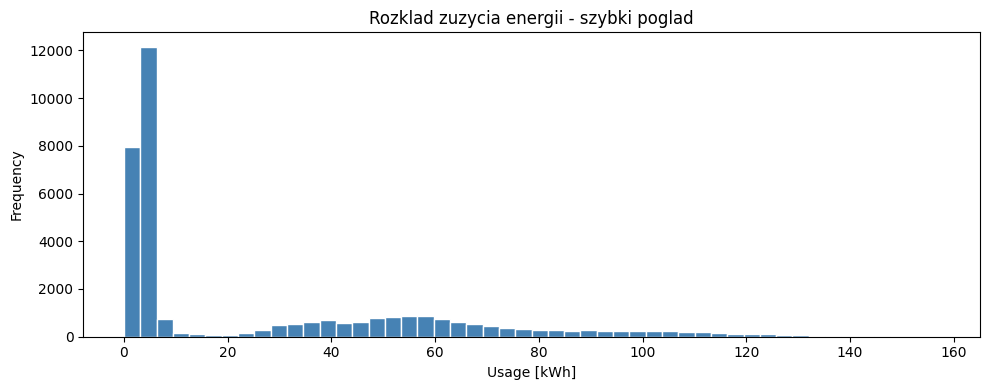

In [8]:
df['Usage_kWh'].plot(
    kind='hist', bins=50, figsize=(10, 4),
    color='steelblue', edgecolor='white',
    title='Rozklad zuzycia energii - szybki poglad'
)
plt.xlabel('Usage [kWh]')
plt.tight_layout()
plt.show()

Rozklad zuzycia energii jest prawostronnie skosny - wiekszosc pomiarow skupia sie w niskich wartosciach, ale zdarzaja sie wyrrazne piki wysokiego obciazenia (np. rozruch piecow). Ten wykres pojawi sie w dopracowanej formie w sekcji Dashboard.

# 3. Czyszczenie i przetworzenie danych

Zbior nie zawiera brakow danych, jednak wymaga kilku przeksztalcen:
- kolumna NSM (sekundy od polnocy) -> czytelna pora doby
- nowa kolumna binarna: czy zuzycie powyzej mediany
- nowa kolumna: przedzialy wspolczynnika mocy (jakosc poboru energii)

In [9]:
# Godzina z NSM (sekundy od polnocy)
df['hour'] = (df['NSM'] // 3600).astype(int)

# Pora doby
df['pora_dnia'] = pd.cut(
    df['hour'],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=['Noc', 'Rano', 'Poludnie', 'Popoludnie', 'Wieczor']
)

print(df['pora_dnia'].value_counts())
df[['NSM', 'hour', 'pora_dnia']].head(8)

pora_dnia
Noc           8760
Rano          8760
Poludnie      7300
Popoludnie    5840
Wieczor       4380
Name: count, dtype: int64


,NSM,hour,pora_dnia
0,900,0,Noc
1,1800,0,Noc
2,2700,0,Noc
3,3600,1,Noc
4,4500,1,Noc
5,5400,1,Noc
6,6300,1,Noc
7,7200,2,Noc


NSM podzielono na 5 por doby. Pozwoli to zbadac rytm dobowy zuzycia energii w hucie - kluczowe z punktu widzenia zarzadzania obciazeniem sieci.

In [10]:
# Kolumna binarna: pobor powyzej mediany (4.57 kWh)
mediana_kwh = df['Usage_kWh'].median()
df['wysoki_pobor'] = (df['Usage_kWh'] > mediana_kwh).astype(int)

print(f"Mediana zuzycia: {mediana_kwh} kWh")
print(df['wysoki_pobor'].value_counts())

Mediana zuzycia: 4.57 kWh
wysoki_pobor
0    17605
1    17435
Name: count, dtype: int64


Kolumna `wysoki_pobor` (0/1) dzieli obserwacje na te o niskim i wysokim zuzyciu wzgledem mediany (4.57 kWh). Przy tak skosnym rozkladzie mediana jest lepszym progiem niz srednia - nie jest zaburzona przez ekstremalne piki produkcyjne.

In [11]:
# Przedzialy jakosci wspolczynnika mocy opoznionej
df['jakosc_mocy'] = pd.cut(
    df['Lagging_Current_Power_Factor'],
    bins=[-1, 60, 80, 90, 100],
    labels=['Zla (<60)', 'Srednia (60-80)', 'Dobra (80-90)', 'Bardzo dobra (>90)']
)

print(df['jakosc_mocy'].value_counts().sort_index())

jakosc_mocy
Zla (<60)              7555
Srednia (60-80)        6341
Dobra (80-90)          5323
Bardzo dobra (>90)    15821
Name: count, dtype: int64


Wspolczynnik mocy opoznionej ponizej 60 oznacza slaba jakosc poboru - huta jest narazona na kary od dostawcy energii. Podzial na 4 kategorie pozwoli wizualizowac jak czesto instalacja pracuje w poszczegolnych zakresach.

# 4. Agregacja danych

Ponizej trzy niezalezne agregacje odpowiadajace na postawione pytania badawcze.

In [12]:
# Agregacja 1: srednie zuzycie energii wg dnia tygodnia i statusu
kolejnosc_dni = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

agg1 = (df.groupby(['Day_of_week', 'WeekStatus'])['Usage_kWh']
          .agg(['mean', 'median', 'std', 'max'])
          .round(2)
          .reindex(kolejnosc_dni, level='Day_of_week'))
print(agg1)

                         mean  median    std     max
Day_of_week WeekStatus                              
Monday      Weekday     33.14    6.28  35.39  153.14
Tuesday     Weekday     34.43    9.29  35.83  151.67
Wednesday   Weekday     32.25    5.85  35.71  149.18
Thursday    Weekday     35.11   19.85  36.42  157.18
Friday      Weekday     33.20    9.02  34.71  151.31
Saturday    Weekend     15.92    3.74  23.65  133.42
Sunday      Weekend      7.55    3.20  14.19  116.78


Roznica miedzy dniami roboczymi a weekendem jest wyrazna:
- Dni robocze: srednie zuzycie **32-35 kWh**, czwartek jest najwyzszy (**35.11 kWh** srednia, mediana **19.85 kWh**)
- Sobota spada do **15.92 kWh**, niedziela do zaledwie **7.55 kWh** - huta w niedziele pracuje prawdopodobnie tylko w trybie podtrzymania.

Duze odchylenie standardowe (std ok. 35) przy medianie kilku kWh potwierdza wczesniejsza
obserwacje: przez wiekszosc czasu zuzycie jest niskie, ale krotkie piki produkcyjne
(do 157 kWh w czwartek) mocno zawyrzaja srednia.

Niedziela ma najnizsze std (**14.19**) - najmniej zmiennosci, dominuje tryb postojowy.

In [13]:
# Agregacja 2: pivot - srednie CO2 wg pory doby i WeekStatus
pivot_co2 = pd.pivot_table(
    df,
    values='CO2(tCO2)',
    index='pora_dnia',
    columns='WeekStatus',
    aggfunc='mean',
    observed=False
).round(4)
print(pivot_co2)

WeekStatus  Weekday  Weekend
pora_dnia                   
Noc          0.0009   0.0009
Rano         0.0195   0.0069
Poludnie     0.0243   0.0086
Popoludnie   0.0228   0.0015
Wieczor      0.0042   0.0008


Emisja CO2 wyraznie rozni sie miedzy dniami roboczymi a weekendem:
- Szczyt emisji w dni robocze przypada na **Poludnie (0.0243 tCO2)** i **Popoludnie (0.0228 tCO2)**
  - pokrywa sie z godzinami pelnej produkcji.
- W weekendy emisja jest 2-15x nizsza: Popoludnie spada z 0.0228 do **0.0015 tCO2**,
  co oznacza ze huta w sobote po poludniu i w niedziele praktycznie nie produkuje.
- Noc ma niemal identyczna emisje w obu typach dni (**0.0009 tCO2**) - minimalne
  obciazenie podtrzymujace piece w temperaturze.

In [14]:
# Agregacja 3: statystyki mocy biernej wg jakosci poboru mocy
agg3 = (df.groupby('jakosc_mocy', observed=False)['Lagging_Current_Reactive.Power_kVarh']
          .agg(['mean', 'median', 'max', 'count'])
          .round(2))
agg3.columns = ['Srednia', 'Mediana', 'Maks', 'Liczba_obserwacji']
print(agg3)

                    Srednia  Mediana   Maks  Liczba_obserwacji
jakosc_mocy                                                   
Zla (<60)              5.26     5.15  18.00               7555
Srednia (60-80)        9.75     4.18  96.91               6341
Dobra (80-90)         33.50    33.95  93.20               5323
Bardzo dobra (>90)    11.18     0.94  70.49              15821


Zaleznosc miedzy jakoscia wspolczynnika mocy a moca bierna jest nieoczywista:

- Kategoria **"Dobra (80-90)"** ma najwyzsza srednia moc bierna (**33.50 kVArh**)
  i mediana (33.95) jest bliska sredniej - to stabilny stan pracy,
  nie efekt outlierow. To typowy tryb aktywnej produkcji przy czesciowej kompensacji.
- Kategoria **"Bardzo dobra (>90)"** ma najnizsza medianie (**0.94 kVArh**) mimo
  najwiekszej liczby obserwacji (15 821) - huta przez wiekszosc czasu pobiera
  minimalna moc bierna przy dobrym wspolczynniku. Wysokie max (70.49) to chwilowe piki.
- Kategoria **"Zla (<60)"** ma zaskakujaco niska moc bierna (srednia 5.26) -
  oznacza to ze slaby wspolczynnik mocy moze tu wynikac z bardzo malego poboru mocy
  czynnej (mianownik), a nie z nadmiernej mocy biernej.

# 5. Dashboard wizualizacyjny

Ponizej 8 wykresow pogrupowanych tematycznie, ilustrujacych rytm dobowy i tygodniowy zuzycia energii, jakosc poboru mocy oraz emisje CO2.

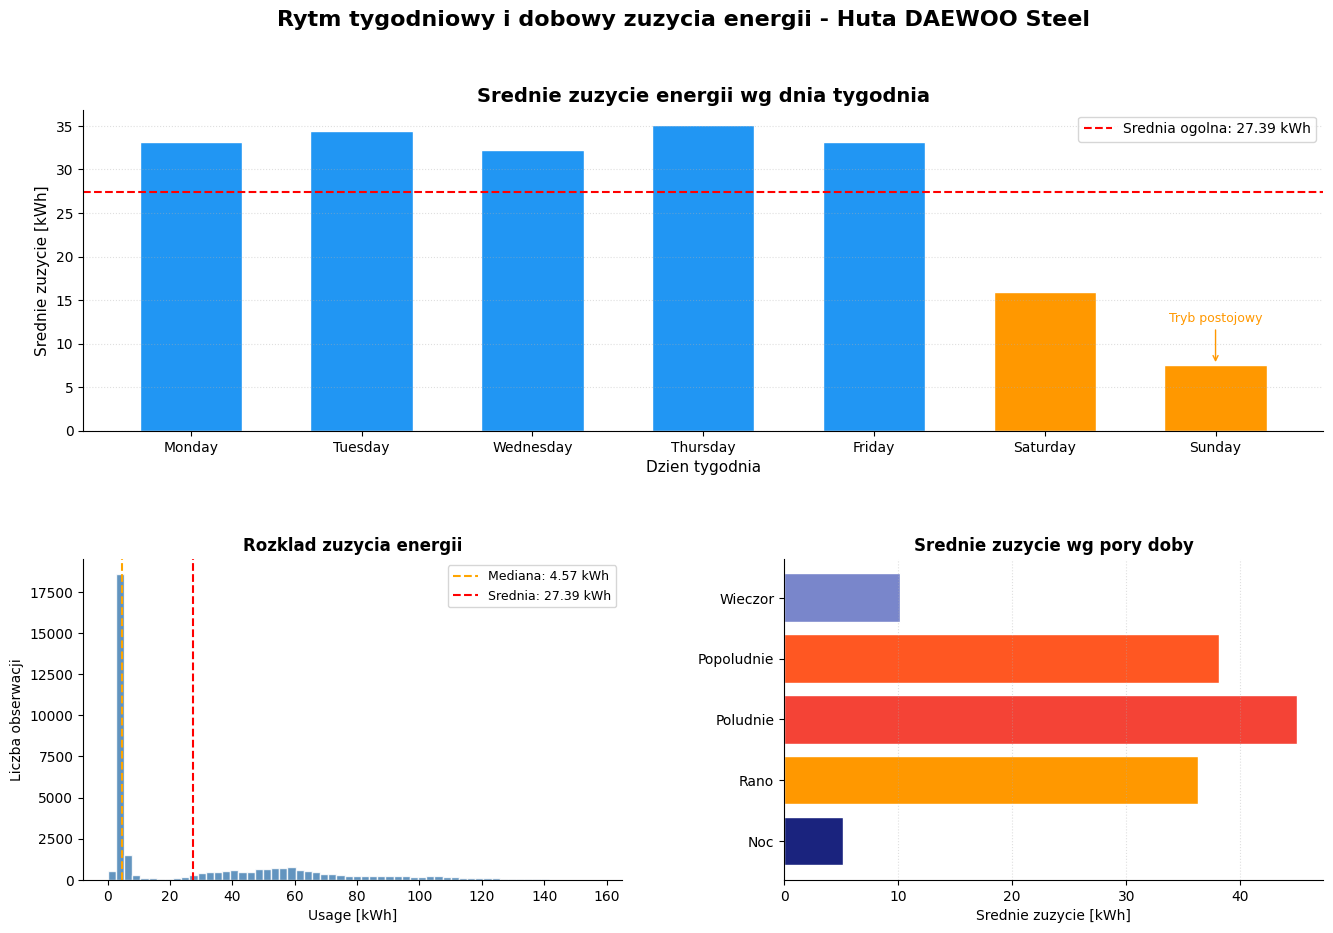

In [15]:
kolejnosc_dni = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
srednie_dni = (df.groupby('Day_of_week')['Usage_kWh']
                 .mean()
                 .reindex(kolejnosc_dni))

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# --- Wykres 1: slupkowy wg dnia tygodnia (gorny, szeroki) ---
ax1 = fig.add_subplot(gs[0, :])
kolory_dni = ['#2196F3']*5 + ['#FF9800']*2
ax1.bar(srednie_dni.index, srednie_dni.values,
        color=kolory_dni, edgecolor='white', width=0.6)
ax1.set_title('Srednie zuzycie energii wg dnia tygodnia',
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Srednie zuzycie [kWh]', fontsize=11)
ax1.set_xlabel('Dzien tygodnia', fontsize=11)
ax1.axhline(df['Usage_kWh'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Srednia ogolna: {df["Usage_kWh"].mean():.2f} kWh')
ax1.legend(fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, axis='y', linestyle=':', alpha=0.4)
ax1.annotate('Tryb postojowy', xy=('Sunday', srednie_dni['Sunday']),
             xytext=('Sunday', srednie_dni['Sunday'] + 5),
             ha='center', fontsize=9, color='#FF9800',
             arrowprops=dict(arrowstyle='->', color='#FF9800'))

# --- Wykres 2: histogram zuzycia (dolny lewy) ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(df['Usage_kWh'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax2.set_title('Rozklad zuzycia energii', fontsize=12, fontweight='bold')
ax2.set_xlabel('Usage [kWh]', fontsize=10)
ax2.set_ylabel('Liczba obserwacji', fontsize=10)
ax2.axvline(df['Usage_kWh'].median(), color='orange', linestyle='--',
            label=f'Mediana: {df["Usage_kWh"].median():.2f} kWh')
ax2.axvline(df['Usage_kWh'].mean(), color='red', linestyle='--',
            label=f'Srednia: {df["Usage_kWh"].mean():.2f} kWh')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Wykres 3: barh pory doby (dolny prawy) ---
ax3 = fig.add_subplot(gs[1, 1])
srednie_pora = (df.groupby('pora_dnia', observed=False)['Usage_kWh']
                  .mean()
                  .reindex(['Noc','Rano','Poludnie','Popoludnie','Wieczor']))
kolory_pora = ['#1a237e','#FF9800','#F44336','#FF5722','#7986CB']
ax3.barh(srednie_pora.index, srednie_pora.values, color=kolory_pora, edgecolor='white')
ax3.set_title('Srednie zuzycie wg pory doby', fontsize=12, fontweight='bold')
ax3.set_xlabel('Srednie zuzycie [kWh]', fontsize=10)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(True, axis='x', linestyle=':', alpha=0.4)

fig.suptitle('Rytm tygodniowy i dobowy zuzycia energii - Huta DAEWOO Steel',
             fontsize=16, fontweight='bold')
plt.show()

## Uzasadnienie wyborow - Wykresy 1, 2, 3

**Wykres 1 (slupkowy + linia sredniej):** Wykres slupkowy najlepiej porownuje
dyskretne kategorie (dni tygodnia). Linia sredniej ogolnej jako punkt odniesienia
pozwala od razu ocenic ktore dni sa powyzej/ponizej normy. Kolorystyka
(niebieski = Weekday, pomaranczowy = Weekend) wzmacnia podzial wizualnie.
Wniosek: weekend to wyrazny spadek produkcji, niedziela to tryb postojowy.

**Wykres 2 (histogram):** Rozklad prawostronnie skosny potwierdza ze huta przez
wiekszosc czasu pracuje na niskim poborze. Dwie linie (mediana i srednia) pokazuja
rozjazd charakterystyczny dla skosnych rozkladow - sama srednia bylaby mylaca.

**Wykres 3 (barh):** Poziomy wykres slupkowy zastosowano celowo - etykiety por doby
sa dlugie i czytelniejsze na osi Y niz pod osia X. Pytanie: kiedy huta zuzrywa
najwiecej energii? Odpowiedz widac natychmiast.

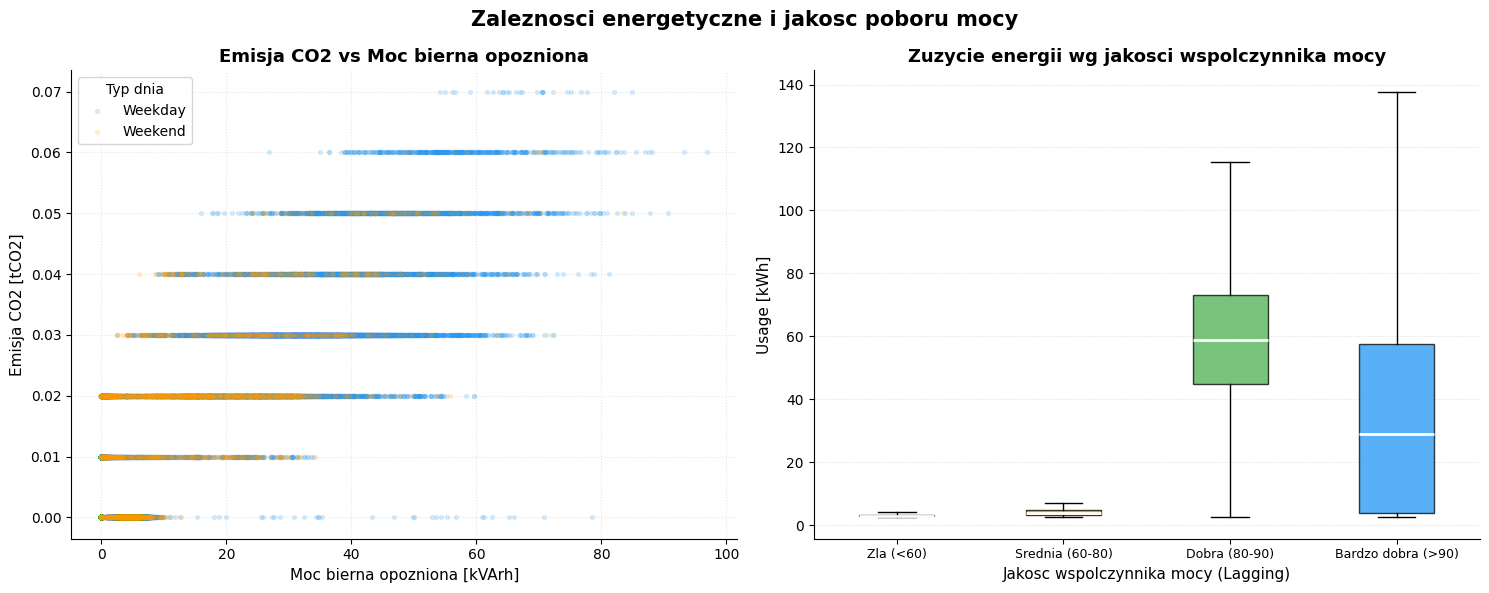

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Wykres 4: scatter CO2 vs moc bierna ---
ax4 = axes[0]
kolory_status = {'Weekday': '#2196F3', 'Weekend': '#FF9800'}
for status, grupa in df.groupby('WeekStatus'):
    ax4.scatter(grupa['Lagging_Current_Reactive.Power_kVarh'],
                grupa['CO2(tCO2)'],
                color=kolory_status[status],
                alpha=0.15, s=8, label=status)
ax4.set_title('Emisja CO2 vs Moc bierna opozniona', fontsize=13, fontweight='bold')
ax4.set_xlabel('Moc bierna opozniona [kVArh]', fontsize=11)
ax4.set_ylabel('Emisja CO2 [tCO2]', fontsize=11)
ax4.legend(title='Typ dnia', fontsize=10)
ax4.grid(True, linestyle=':', alpha=0.3)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# --- Wykres 5: boxplot zuzycia wg jakosci mocy ---
ax5 = axes[1]
kolejnosc_kat = ['Zla (<60)', 'Srednia (60-80)', 'Dobra (80-90)', 'Bardzo dobra (>90)']
dane_box = [df[df['jakosc_mocy'] == k]['Usage_kWh'].dropna() for k in kolejnosc_kat]
bp = ax5.boxplot(dane_box, patch_artist=True, showfliers=False,
                 medianprops=dict(color='white', linewidth=2))
kolory_box = ['#F44336','#FF9800','#4CAF50','#2196F3']
for patch, kolor in zip(bp['boxes'], kolory_box):
    patch.set_facecolor(kolor)
    patch.set_alpha(0.75)
ax5.set_xticklabels(kolejnosc_kat, fontsize=9)
ax5.set_title('Zuzycie energii wg jakosci wspolczynnika mocy', fontsize=13, fontweight='bold')
ax5.set_ylabel('Usage [kWh]', fontsize=11)
ax5.set_xlabel('Jakosc wspolczynnika mocy (Lagging)', fontsize=11)
ax5.grid(True, axis='y', linestyle=':', alpha=0.4)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

fig.suptitle('Zaleznosci energetyczne i jakosc poboru mocy', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Uzasadnienie - Wykres 4 (scatter)

Wykres punktowy wybrano do zbadania zaleznosci miedzy moca bierna opozniona
a emisja CO2, poniewaz pozwala zobaczyc ksztalt zaleznosci miedzy dwiema
zmiennymi ciaglymi - czy jest liniowa, skupiona, czy rozproszona.
Kolorowanie punktow wedlug typu dnia (Weekday/Weekend) dodaje trzeci wymiar
bez komplikowania wykresu.

Pytanie: czy wyzsza moc bierna zawsze oznacza wyzsza emisje CO2?
Wniosek: zaleznosc jest dodatnia i wyrazna - punkty Weekday siegaja wyzszych
wartosci obu osi, co potwierdza ze dni robocze to intensywniejsza praca instalacji.
Niska przezroczystosc punktow (alpha=0.15) byla konieczna przy 35 000 obserwacjach
- bez tego wykres bylby jednolita plama.

## Uzasadnienie - Wykres 5 (boxplot)

Boxplot wybrano zamiast wykresu slupkowego, poniewaz samo porownanie srednich
byloby mylace przy tak skosnym rozkladzie. Boxplot pokazuje jednoczesnie mediане,
rozstep kwartylowy i zasieg danych - dla kazdej z 4 kategorii jakosci mocy.
Outliery ukryto (showfliers=False) dla czytelnosci - przy 35 000 obserwacjach
zasmiecalyby wykres.

Pytanie: jaki tryb pracy odpowiada jakiej jakosci poboru mocy?
Wniosek: kategoria "Dobra (80-90)" ma najwyzsza medianie zuzycia - to tryb
aktywnej produkcji. "Bardzo dobra" ma medianie bliska zeru - dominuje stan postoju.

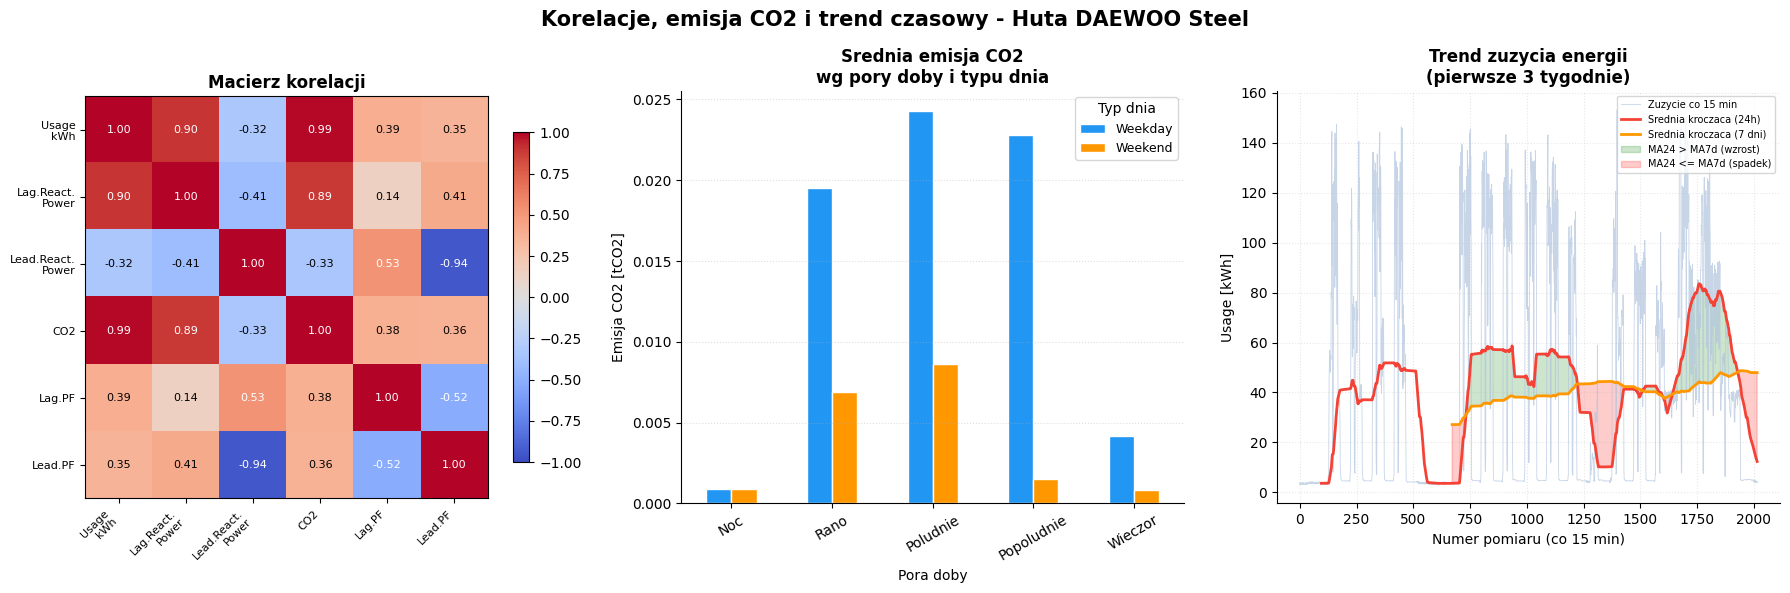

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Wykres 6: heatmapa korelacji ---
ax6 = axes[0]
kolumny_num = ['Usage_kWh',
               'Lagging_Current_Reactive.Power_kVarh',
               'Leading_Current_Reactive_Power_kVarh',
               'CO2(tCO2)',
               'Lagging_Current_Power_Factor',
               'Leading_Current_Power_Factor']
korelacja = df[kolumny_num].corr()
im = ax6.imshow(korelacja, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax6, shrink=0.8)
etykiety = ['Usage\nkWh', 'Lag.React.\nPower', 'Lead.React.\nPower',
            'CO2', 'Lag.PF', 'Lead.PF']
ax6.set_xticks(range(6))
ax6.set_xticklabels(etykiety, fontsize=8, rotation=45, ha='right')
ax6.set_yticks(range(6))
ax6.set_yticklabels(etykiety, fontsize=8)
for i in range(6):
    for j in range(6):
        val = korelacja.iloc[i, j]
        kol = 'white' if abs(val) > 0.5 else 'black'
        ax6.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=kol)
ax6.set_title('Macierz korelacji', fontsize=12, fontweight='bold')

# --- Wykres 7: pivot CO2 wg pory dnia i WeekStatus ---
ax7 = axes[1]
pivot_plot = pivot_co2.reindex(['Noc', 'Rano', 'Poludnie', 'Popoludnie', 'Wieczor'])
pivot_plot.plot(kind='bar', ax=ax7, color=['#2196F3', '#FF9800'],
                edgecolor='white', rot=30)
ax7.set_title('Srednia emisja CO2\nwg pory doby i typu dnia', fontsize=12, fontweight='bold')
ax7.set_ylabel('Emisja CO2 [tCO2]', fontsize=10)
ax7.set_xlabel('Pora doby', fontsize=10)
ax7.legend(title='Typ dnia', fontsize=9)
ax7.grid(True, axis='y', linestyle=':', alpha=0.4)
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)

# --- Wykres 8: szereg czasowy z rolling mean + fill_between ---
ax8 = axes[2]
probka = df['Usage_kWh'].iloc[:2016].reset_index(drop=True)
ma24 = probka.rolling(96).mean()
ma7d = probka.rolling(672).mean()

ax8.plot(probka, color='lightsteelblue', linewidth=0.6, alpha=0.7, label='Zuzycie co 15 min')
ax8.plot(ma24, color='#F44336', linewidth=2, label='Srednia kroczaca (24h)')
ax8.plot(ma7d, color='#FF9800', linewidth=2, label='Srednia kroczaca (7 dni)')

# fill_between - zacieniowanie miedzy srednimi kroczacymi
ax8.fill_between(probka.index, ma24, ma7d,
                 where=(ma24 > ma7d), alpha=0.2, color='green',
                 label='MA24 > MA7d (wzrost)')
ax8.fill_between(probka.index, ma24, ma7d,
                 where=(ma24 <= ma7d), alpha=0.2, color='red',
                 label='MA24 <= MA7d (spadek)')

ax8.set_title('Trend zuzycia energii\n(pierwsze 3 tygodnie)', fontsize=12, fontweight='bold')
ax8.set_ylabel('Usage [kWh]', fontsize=10)
ax8.set_xlabel('Numer pomiaru (co 15 min)', fontsize=10)
ax8.legend(fontsize=7)
ax8.grid(True, linestyle=':', alpha=0.3)
ax8.spines['top'].set_visible(False)
ax8.spines['right'].set_visible(False)

fig.suptitle('Korelacje, emisja CO2 i trend czasowy - Huta DAEWOO Steel',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Uzasadnienie - Wykres 6 (heatmapa korelacji)

Heatmapa to najefektywniejszy sposob prezentacji macierzy korelacji dla wielu
zmiennych jednoczesnie - 6x6 = 36 wartosci w jednym czytelnym obrazku.
Skala coolwarm (czerwony = dodatnia, niebieski = ujemna) pozwala natychmiast
wychwycic silne zaleznosci bez czytania liczb.

Pytanie: ktore zmienne sa ze soba powiazane?
Wniosek: Usage_kWh i CO2 sa silnie skorelowane - kazda produkcja generuje
proporcjonalna emisje. Wspolczynnik mocy opoznionej jest ujemnie skorelowany
z moca bierna opozniona - im wyzsza moc bierna, tym gorszy wspolczynnik mocy.

## Uzasadnienie - Wykres 7 (grouped bar z pivot)

Zgrupowany wykres slupkowy z tabeli przestawnej pozwala porownac dwa wymiary
jednoczesnie - pore doby (5 kategorii) i typ dnia (Weekday/Weekend) - w jednym
czytelnym obrazku. Alternatywa bylaby heatmapa, ale przy tylko 2 kolumnach
(WeekStatus) wykres slupkowy jest czytelniejszy i latwiej odczytac konkretne wartosci.

Pytanie: czy rytm dobowy emisji CO2 rozni sie miedzy dniem roboczym a weekendem?
Wniosek: w dni robocze emisja jest 2-15x wyzsza niz w weekend, szczyt przypada
na Poludnie i Popoludnie. W weekendy emisja jest niemal plaska przez cala dobe.

## Uzasadnienie - Wykres 8 (szereg czasowy + srednie kroczace + fill_between)

Wykres liniowy to jedyna sensowna forma dla danych szeregu czasowego -
pokazuje kolejnosc i ciaglosc pomiarow w czasie. Surowe dane co 15 minut
sa zbyt zaszumione do interpretacji, dlatego dodano dwie srednie kroczace:
24-godzinna (96 pomiarow) i 7-dniowa (672 pomiary).

Obszary fill_between miedzy srednimi kroczacymi (zielony = MA24 powyzej MA7d,
czerwony = ponizej) wizualnie sygnalizuja krotkoterminowe przyspieszenia
i spowolnienia produkcji wzgledem trendu tygodniowego - technika analogiczna
do analizy technicznej na wykresach finansowych.

Pytanie: czy widac regularny rytm tygodniowy w zuzyciu energii?
Wniosek: srednia kroczaca 24h ujawnia wyrazne piki produkcyjne w dni robocze
i spadki w weekendy - regularny wzorzec powtarza sie co 7 dni.

In [18]:
# Eksport wykresu do pliku PNG (>=200 dpi)
fig.savefig('dashboard_steel.png', dpi=200, bbox_inches='tight')

# Weryfikacja
if os.path.exists('dashboard_steel.png'):
    rozmiar = os.path.getsize('dashboard_steel.png') / 1024
    print(f"dashboard_steel.png zapisany ({rozmiar:.1f} KB, 200 dpi)")
else:
    print("Plik nie zostal zapisany")

dashboard_steel.png zapisany (418.9 KB, 200 dpi)


# 6. Odpowiedzi na pytania badawcze

**Pytanie 1: Jak zmienia sie zuzycie energii w zaleznosci od dnia tygodnia i typu dnia?**
Zuzycie energii jest wyraznie wyzsze w dni robocze (srednia 32-35 kWh) niz w weekend.
Najwyzsze zuzycie notuje czwartek (35.11 kWh), najnizsze niedziela (7.55 kWh - zaledwie 22%
wartosci czwartkowej). W ciagu doby szczyt przypada na Poludnie i Popoludnie (godz. 11-20),
noc to czas minimalnego podtrzymania instalacji. Widoczne na wykresach 1, 3 i 8.

**Pytanie 2: Czy istnieje zwiazek miedzy emisja CO2 a moca bierna opozniona?**
Tak - zaleznosc jest dodatnia i wyrazna (widoczna na wykresie 4 oraz macierzy korelacji).
Im wyzsza moc bierna opozniona, tym wieksza emisja CO2 - obie zmienne rosna jednoczesnie
podczas aktywnej produkcji. Punkty Weekday siegaja wyzszych wartosci obu osi niz Weekend,
co potwierdza ze intensywniejsza praca instalacji generuje proporcjonalnie wiecej emisji.

**Pytanie 3: O jakiej porze doby zuzycie energii jest najwieksze?**
Najwieksze zuzycie energii wystepuje w porze Poludnie (godz. 11-16) i Popoludnie (godz. 16-20).
Widoczne bezposrednio na wykresie 3 (barh) oraz posrednio na wykresie 8 przez srednia
kroczaca 24h. Noc (godz. 0-5) to zdecydowanie najnizszy pobor - huta pracuje wtedy
jedynie w trybie podtrzymania piecow.


# 7. Wnioski

Analiza zuzycia energii elektrycznej w hucie stali DAEWOO pozwolila odpowiedziec
na wszystkie trzy postawione pytania badawcze:

## Rytm tygodniowy i dobowy
Huta wykazuje bardzo wyrazny rytm produkcyjny. Dni robocze maja srednie zuzycie
32-35 kWh, podczas gdy niedziela spada do 7.55 kWh - zaledwie 22% wartosci
czwartkowej. Szczyt produkcji przypada na godziny 11-20 (Poludnie i Popoludnie),
noc jest czasem minimalnego podtrzymania instalacji.

## Emisja CO2 a typ dnia
Emisja CO2 jest scisle proporcjonalna do zuzycia energii (korelacja widoczna
na heatmapie). W dni robocze poludnie generuje 0.0243 tCO2 na pomiar,
w weekend ta sama pora to tylko 0.0086 tCO2 - spadek o 65%.
Noc ma niemal identyczna emisje niezaleznie od dnia tygodnia (0.0009 tCO2),
co wskazuje na stale minimalne obciazenie podtrzymujace piece w temperaturze.

## Jakosc poboru mocy
Kategoria "Dobra (80-90)" wspolczynnika mocy odpowiada trybowi aktywnej produkcji
- najwyzsza mediana zuzycia (33.95 kWh) i stabilny rozklad. Kategoria
"Bardzo dobra (>90)" dominuje liczbowo (15 821 obserwacji), ale z mediana
zuzycia 0.94 kVArh - to tryb postoju z prawidlowa kompensacja mocy biernej.

## Obserwacja dodatkowa
Rozklad zuzycia energii jest silnie prawostronnie skosny - mediana (4.57 kWh)
jest wielokrotnie nizsza od sredniej (27.39 kWh). Oznacza to, ze huta przez
wiekszosc czasu pracuje na niskim obciazeniu, a krotkie intensywne cykle
produkcyjne (do 157 kWh) mocno zawyrzaja srednia. Przy analizie takich danych
mediana jest miara bardziej reprezentatywna niz srednia.